# Backtesting

As a result of my exploration in `stock-selection.ipynb` and `clustering.ipynb`, I have come to a final selection of stocks that are based on the real estate industry and REIT-Residential sector from Yahoo Finance. Using these stocks I conducted a manual backtest.

## 1. Download data

In [5]:
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

FINAL_TICKERS = ["AMH", "AVB", "CPT", "ELS", "EQR", "IRT", "MAA", "SUI", "UDR", "UMH"]

end_date = "2026-06-30"
start_date = (pd.to_datetime(end_date) - pd.DateOffset(365*12)).strftime('%Y-%m-%d')
df = yf.download(FINAL_TICKERS, start=start_date, end=end_date, auto_adjust=True)['Close']


df = df.dropna(axis=1)

print('df size: ', df.shape)

[*********************100%***********************]  10 of 10 completed

df size:  (3014, 10)


## 2. Implement Strategy

For my first strategy, we will implement single cluster mean reversion. This strategy was taken from [151 Trading Strategies](https://ssrn.com/abstract=3247865) page 46-47. The functions have all been implemented in `backtest.py` as I need to reuse them later in `meta-labelling.ipynb`

In [3]:
from backtest import print_stats, run_benchmark, run_backtest

## 3. Backtesting

### 3.1 Full backtest

Running the strategy on ALL of the downloaded data (~12 years) with no transaction cost

--- Strategy ---
Total return: 179.51%
Sharpe ratio: 1.27
Max drawdown: -8.56%
--- Benchmark ---
Total return: 190.54%
Sharpe ratio: 0.52
Max drawdown: -39.51%


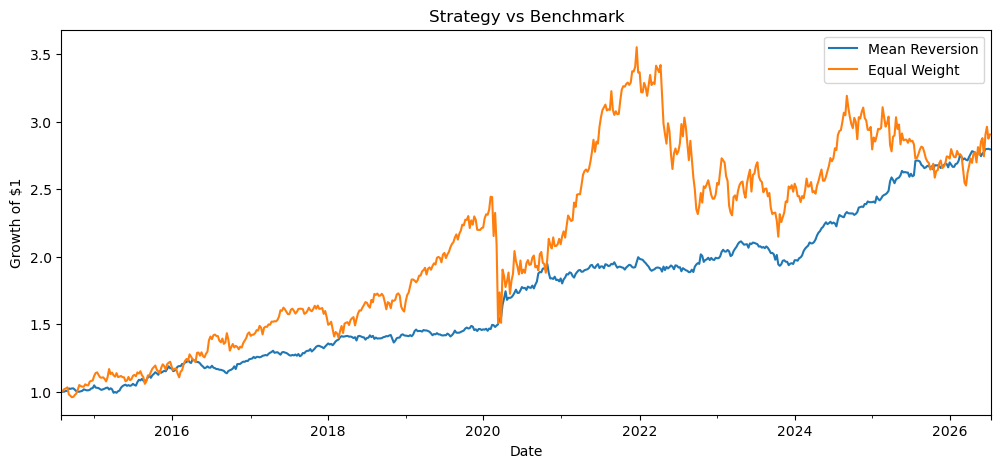

In [4]:
end = df.index.max()
start = df.index.min()

strategy = run_backtest(df, start_date=start, end_date=end, cost_bps=0)
benchmark = run_benchmark(df, start_date=start, end_date=end)

print("--- Strategy ---")
print_stats(strategy["stats"])

print("--- Benchmark ---")
print_stats(benchmark["stats"])


equity = strategy["equity"]
cluster_equity = benchmark["equity"]

plt.figure(figsize=(12, 5))
(equity / equity.iloc[0]).plot(label="Mean Reversion")
(cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
plt.legend()
plt.ylabel("Growth of $1")
plt.title("Strategy vs Benchmark")
plt.show()

### 3.2 Backtest on multiple time periods

To ensure that the results of the algorithm are consistent during different time periods, I tested the strategy on four 3 year periods throughout the 12 years of data.

---- 2014-07-21 00:00:00 to 2017-07-21 00:00:00 ----
Date
2014-08-01   -0.006820
2014-08-08    0.000269
2014-08-15    0.001126
2014-08-22    0.005251
2014-08-29   -0.000587
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 26.81%
Sharpe ratio: 1.17
Max drawdown: -8.33%
--- Benchmark ---
Total return: 60.81%
Sharpe ratio: 1.17
Max drawdown: -9.44%


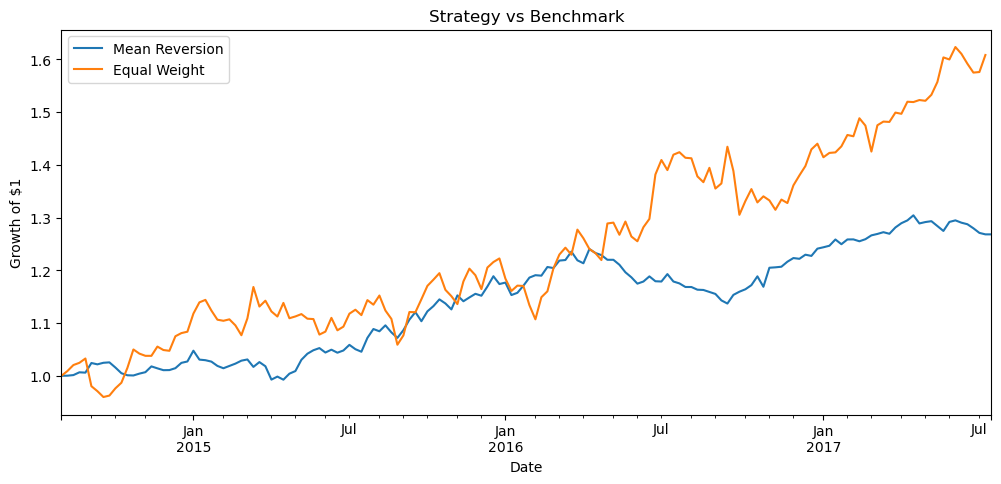

---- 2017-07-21 00:00:00 to 2020-07-21 00:00:00 ----
Date
2017-07-28   -0.002630
2017-08-04    0.005199
2017-08-11   -0.007175
2017-08-18    0.010239
2017-08-25   -0.013072
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 38.67%
Sharpe ratio: 1.48
Max drawdown: -3.92%
--- Benchmark ---
Total return: 16.29%
Sharpe ratio: 0.31
Max drawdown: -38.24%


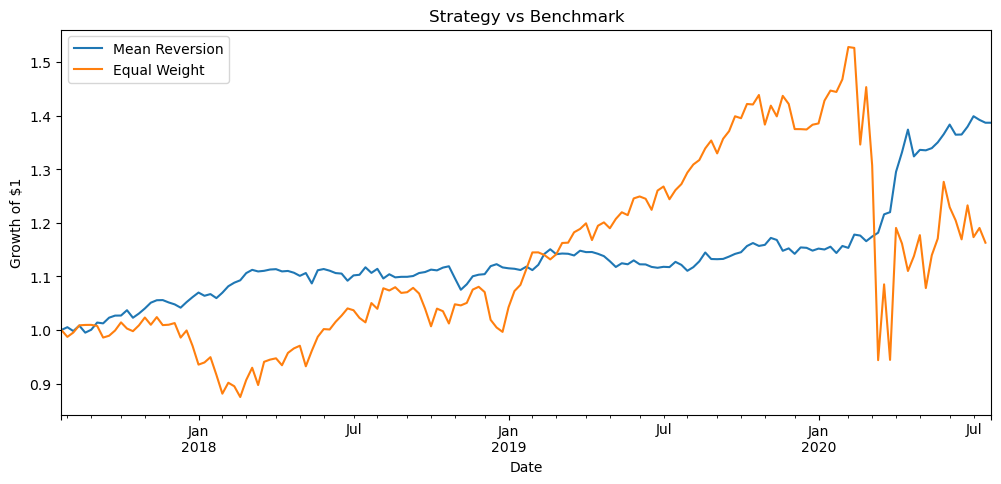

---- 2020-07-21 00:00:00 to 2023-07-21 00:00:00 ----
Date
2020-07-31    0.014207
2020-08-07   -0.004004
2020-08-14   -0.001324
2020-08-21    0.009387
2020-08-28   -0.011579
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 17.64%
Sharpe ratio: 0.86
Max drawdown: -7.49%
--- Benchmark ---
Total return: 36.66%
Sharpe ratio: 0.62
Max drawdown: -35.04%


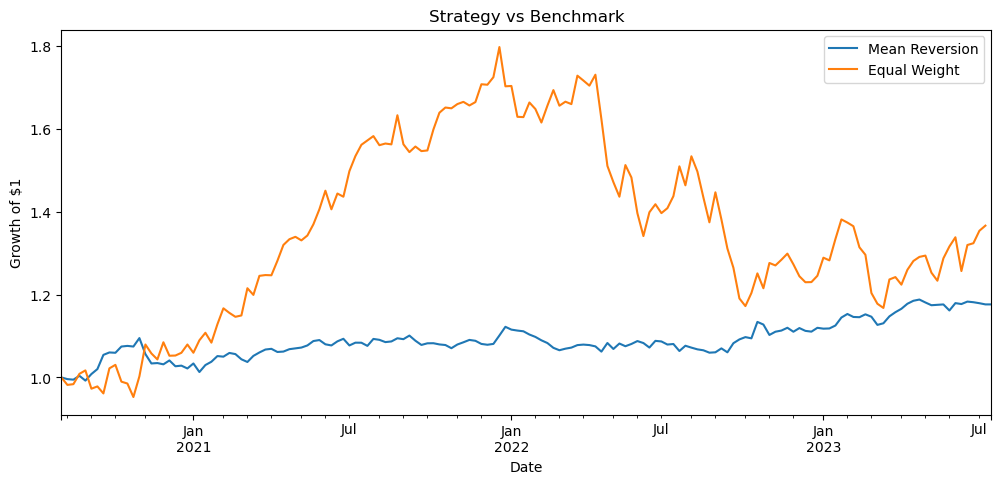

---- 2023-07-21 00:00:00 to 2026-07-17 00:00:00 ----
Date
2023-07-28    0.001072
2023-08-04   -0.004798
2023-08-11    0.002156
2023-08-18   -0.003836
2023-08-25    0.006098
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 34.54%
Sharpe ratio: 1.65
Max drawdown: -6.96%
--- Benchmark ---
Total return: 13.28%
Sharpe ratio: 0.31
Max drawdown: -20.81%


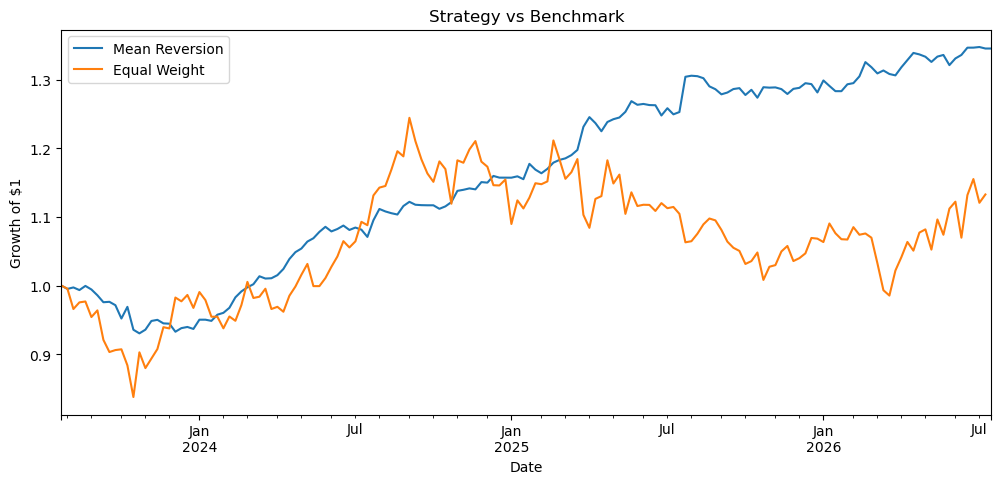

In [4]:
periods = [
    (start, start + pd.DateOffset(years=3)),
    (start + pd.DateOffset(years=3), start + pd.DateOffset(years=6)),
    (start + pd.DateOffset(years=6), start + pd.DateOffset(years=9)),
    (start + pd.DateOffset(years=9), end),
]

for s, e in periods:
    print(f"---- {s} to {e} ----")
    strategy = run_backtest(df, start_date=s, end_date=e, cost_bps=0)
    benchmark = run_benchmark(df, start_date=s, end_date=e)

    print("--- Strategy ---")
    print_stats(strategy["stats"])

    print("--- Benchmark ---")
    print_stats(benchmark["stats"])


    equity = strategy["equity"]
    cluster_equity = benchmark["equity"]

    plt.figure(figsize=(12, 5))
    (equity / equity.iloc[0]).plot(label="Mean Reversion")
    (cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
    plt.legend()
    plt.ylabel("Growth of $1")
    plt.title("Strategy vs Benchmark")
    plt.show()


#### Conclusion

The algorithm performed well on three periods out of the 4, with the 2014-2017, 2017-2020 and 2023-2026 time periods having an average Sharpe Ratio of ~1.45. However, during the 2020-2023 period the Sharpe Ratio dropped below 1 to around 0.8. This suggests the strategy is generally robust across several regimes, but may be less effective during economic uncertainty.

### 3.3 Leave-one-out backtest
This backtest tests the stock cluster for overreliance on one specific stock. For each stock in the cluster, we remove it and run the algorithm on the remaining stocks. If removing any of the one stocks from the cluster significantly reduces the algorithm's result, then the strategy likely depends on that one stock. These were tested on the last three years of data.

Date
2014-08-01   -0.004112
2014-08-08    0.005122
2014-08-15   -0.002536
2014-08-22    0.002652
2014-08-29   -0.003558
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 173.27%
Sharpe ratio: 1.17
Max drawdown: -10.12%
--- Benchmark ---
Total return: 193.51%
Sharpe ratio: 0.52
Max drawdown: -41.04%


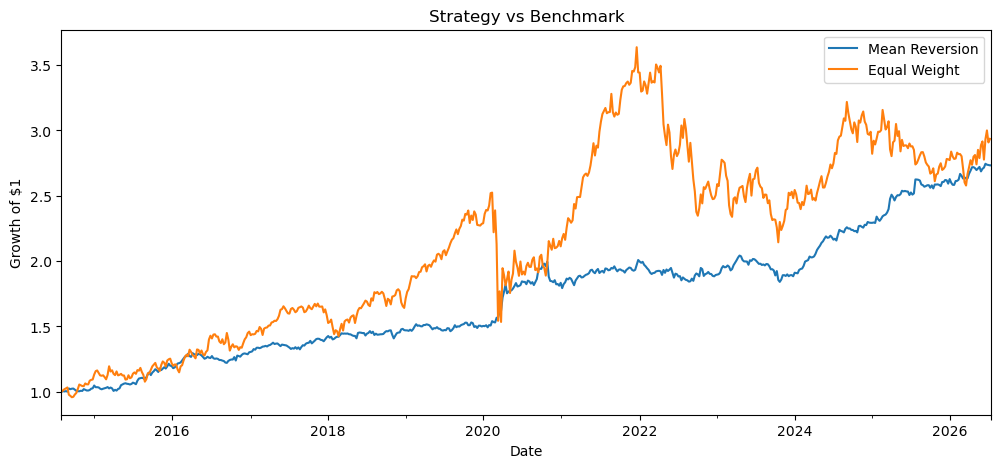

Date
2014-08-01   -0.007621
2014-08-08    0.000304
2014-08-15    0.000973
2014-08-22    0.005641
2014-08-29   -0.000659
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 182.34%
Sharpe ratio: 1.24
Max drawdown: -9.75%
--- Benchmark ---
Total return: 202.37%
Sharpe ratio: 0.53
Max drawdown: -40.40%


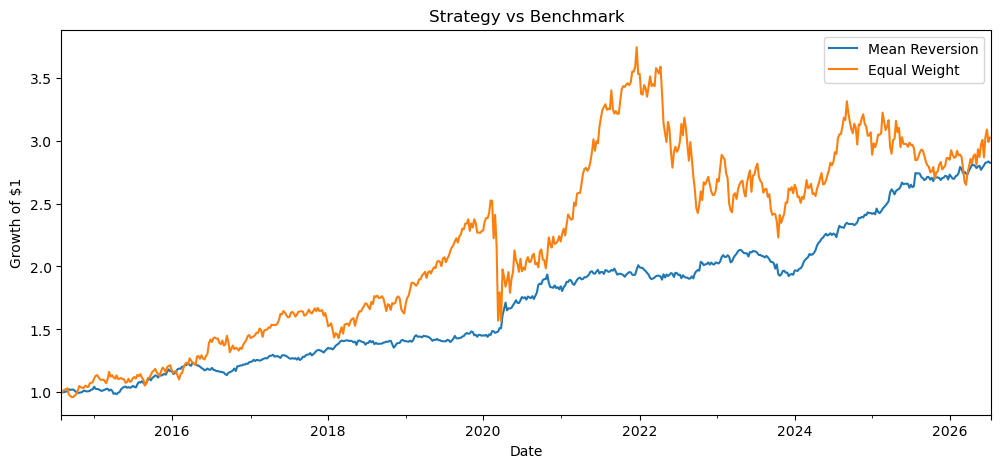

Date
2014-08-01   -0.006921
2014-08-08    0.000155
2014-08-15    0.000497
2014-08-22    0.004892
2014-08-29   -0.000532
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 186.40%
Sharpe ratio: 1.23
Max drawdown: -9.29%
--- Benchmark ---
Total return: 194.02%
Sharpe ratio: 0.52
Max drawdown: -38.25%


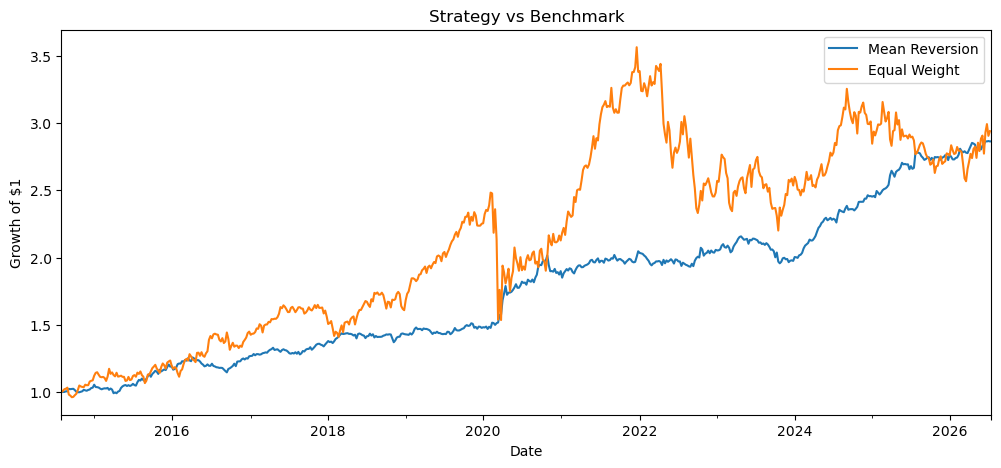

Date
2014-08-01   -0.006873
2014-08-08   -0.000255
2014-08-15    0.000651
2014-08-22    0.004847
2014-08-29   -0.000246
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 169.29%
Sharpe ratio: 1.19
Max drawdown: -10.68%
--- Benchmark ---
Total return: 176.89%
Sharpe ratio: 0.49
Max drawdown: -41.23%


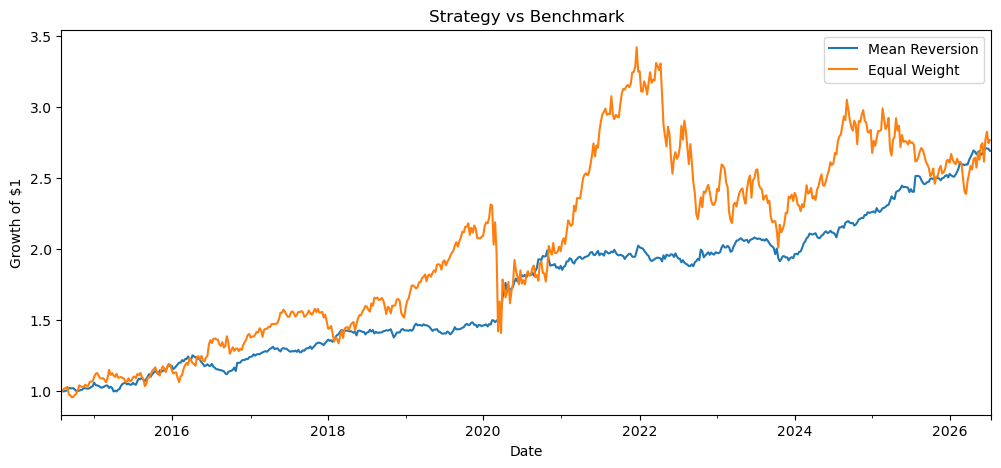

Date
2014-08-01   -0.007002
2014-08-08    0.000357
2014-08-15    0.001158
2014-08-22    0.005256
2014-08-29   -0.000867
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 215.82%
Sharpe ratio: 1.38
Max drawdown: -9.17%
--- Benchmark ---
Total return: 202.20%
Sharpe ratio: 0.53
Max drawdown: -39.97%


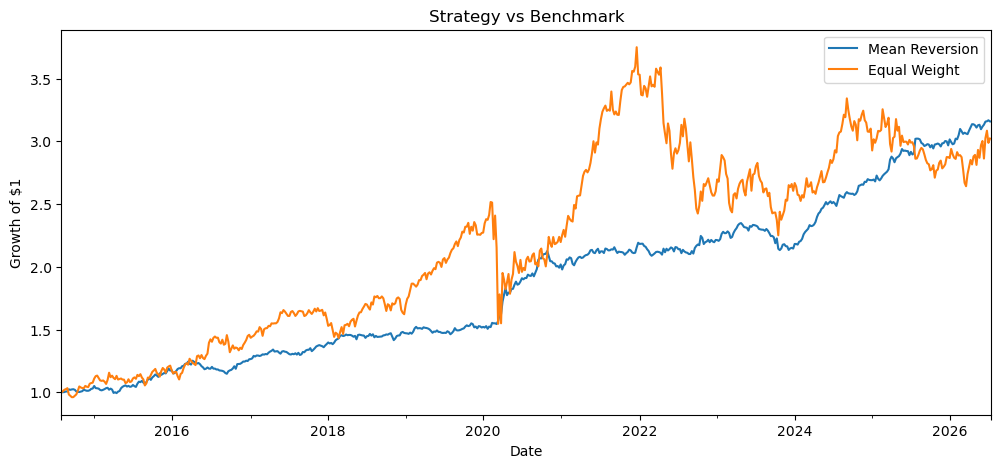

Date
2014-08-01   -0.007954
2014-08-08   -0.000121
2014-08-15    0.008350
2014-08-22    0.003788
2014-08-29    0.003317
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 125.00%
Sharpe ratio: 1.01
Max drawdown: -8.60%
--- Benchmark ---
Total return: 180.47%
Sharpe ratio: 0.51
Max drawdown: -38.41%


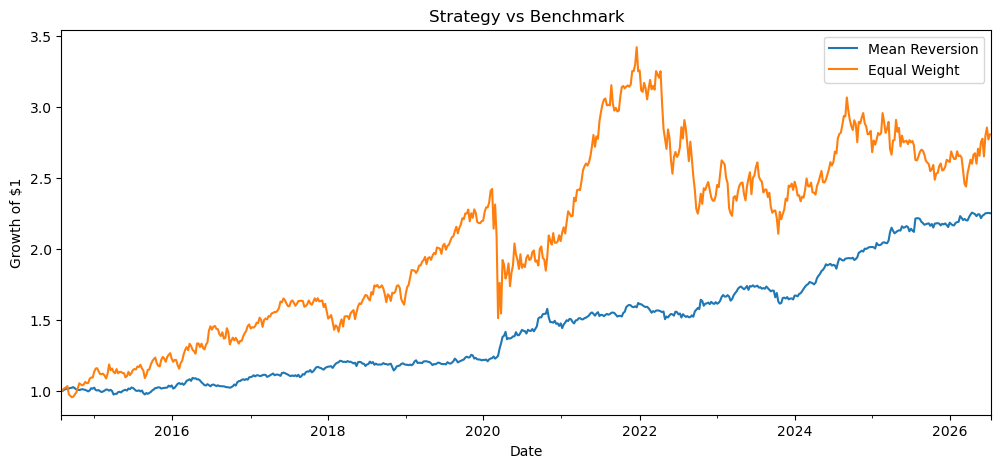

Date
2014-08-01   -0.009908
2014-08-08    0.000326
2014-08-15    0.001235
2014-08-22    0.005260
2014-08-29   -0.000550
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 188.94%
Sharpe ratio: 1.26
Max drawdown: -9.45%
--- Benchmark ---
Total return: 188.66%
Sharpe ratio: 0.52
Max drawdown: -38.86%


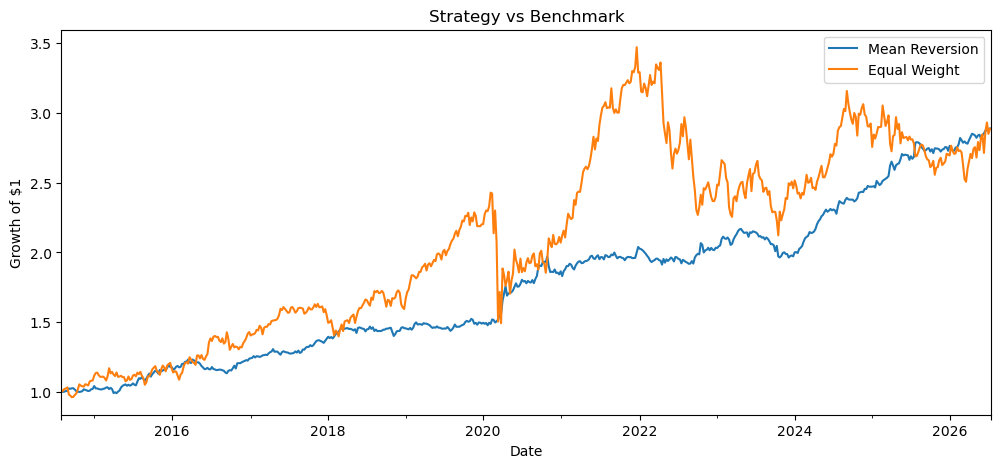

Date
2014-08-01   -0.006325
2014-08-08    0.000477
2014-08-15    0.000690
2014-08-22    0.007915
2014-08-29   -0.000686
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 161.51%
Sharpe ratio: 1.16
Max drawdown: -10.42%
--- Benchmark ---
Total return: 182.12%
Sharpe ratio: 0.50
Max drawdown: -38.92%


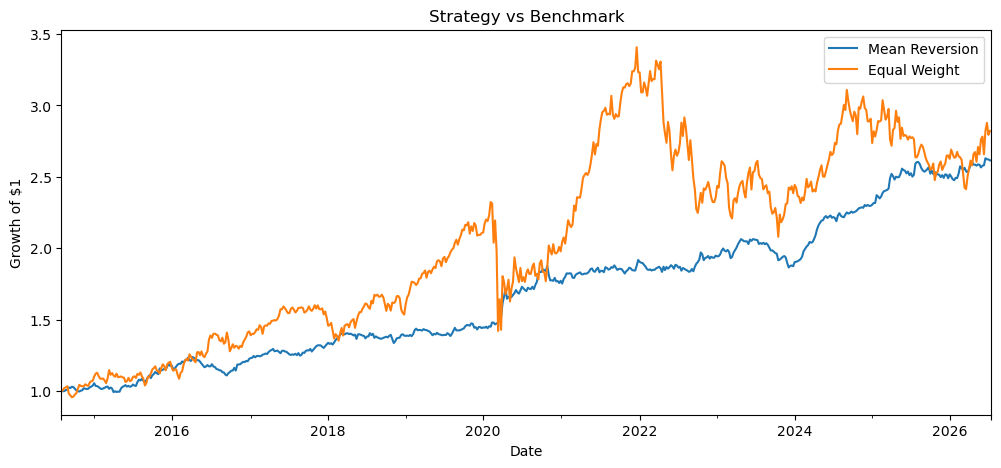

Date
2014-08-01   -0.007072
2014-08-08    0.000138
2014-08-15    0.001416
2014-08-22    0.005330
2014-08-29   -0.000406
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 189.30%
Sharpe ratio: 1.28
Max drawdown: -8.89%
--- Benchmark ---
Total return: 199.71%
Sharpe ratio: 0.53
Max drawdown: -39.11%


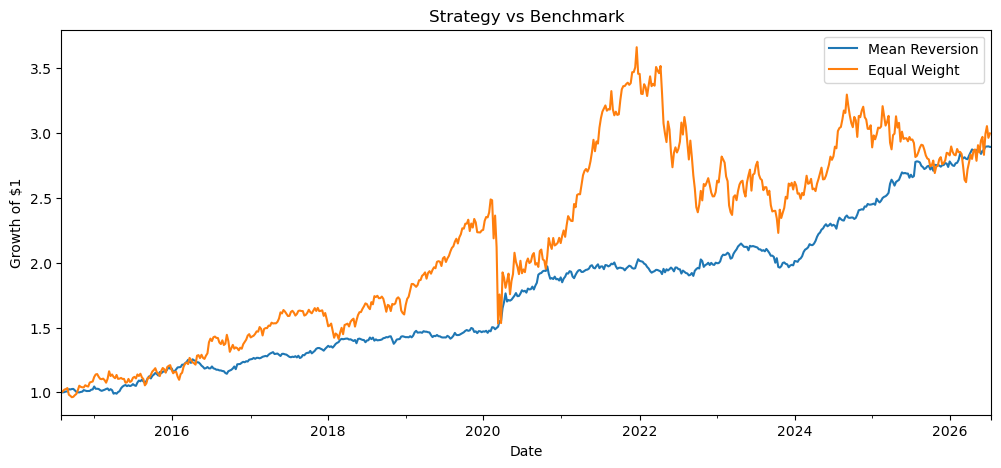

Date
2014-08-01   -0.004872
2014-08-08   -0.003714
2014-08-15   -0.000078
2014-08-22    0.006336
2014-08-29   -0.001846
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 137.02%
Sharpe ratio: 1.04
Max drawdown: -9.20%
--- Benchmark ---
Total return: 183.46%
Sharpe ratio: 0.50
Max drawdown: -38.87%


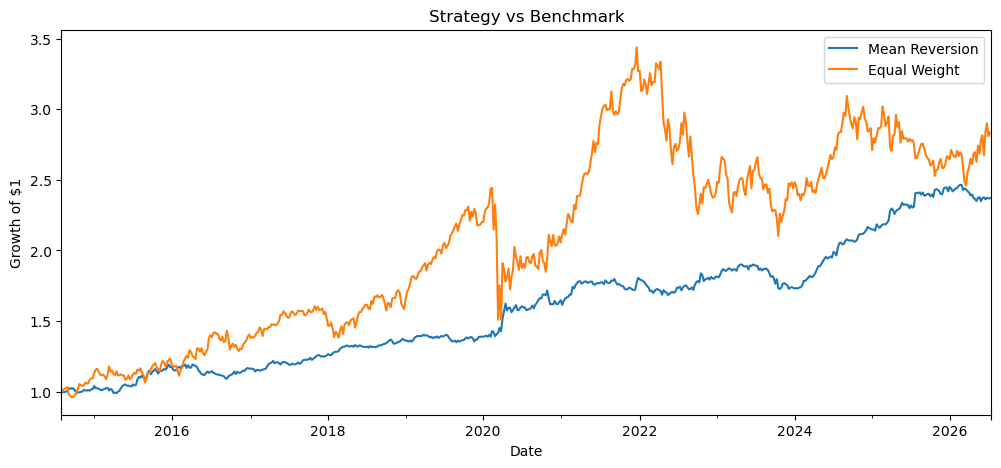

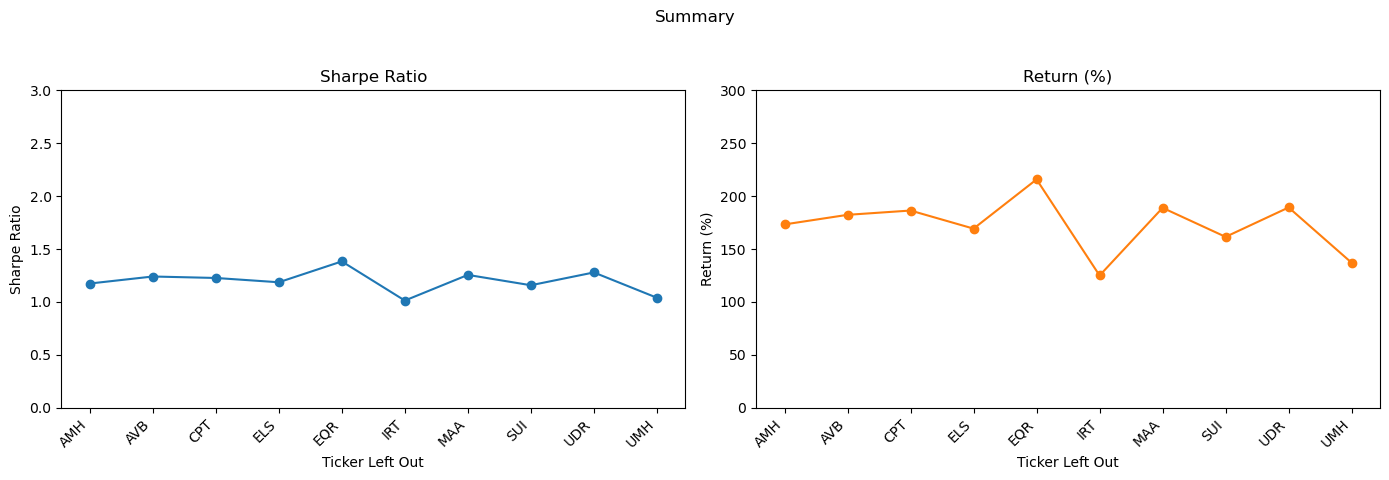

In [5]:
end = df.index.max()
start = end - pd.DateOffset(years=12)

sharpe_ratios = []
returns = []

for i in range(len(FINAL_TICKERS)):
    ticker = FINAL_TICKERS[i]
    df_no_ticker = df.drop(columns=[ticker])
    strategy = run_backtest(df_no_ticker, start_date=start, end_date=end, cost_bps=0)
    benchmark = run_benchmark(df_no_ticker, start_date=start, end_date=end)

    sharpe_ratios.append(strategy["stats"]["sharpe"])
    returns.append(strategy["stats"]["total_return_pct"])

    print("--- Strategy ---")
    print_stats(strategy["stats"])

    print("--- Benchmark ---")
    print_stats(benchmark["stats"])


    equity = strategy["equity"]
    cluster_equity = benchmark["equity"]

    plt.figure(figsize=(12, 5))
    (equity / equity.iloc[0]).plot(label="Mean Reversion")
    (cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
    plt.legend()
    plt.ylabel("Growth of $1")
    plt.title("Strategy vs Benchmark")
    plt.show()


# Plot the Sharpe Ratio and the Return
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Summary")

leaveout_labels = FINAL_TICKERS

axs[0].plot(leaveout_labels, sharpe_ratios, marker='o', linestyle='-')
axs[0].set_title("Sharpe Ratio")
axs[0].set_xlabel("Ticker Left Out")
axs[0].set_ylabel("Sharpe Ratio")
axs[0].set_ylim(bottom=0, top=3)
axs[0].set_xticks(range(len(leaveout_labels)))
axs[0].set_xticklabels(leaveout_labels, rotation=45, ha='right')

axs[1].plot(leaveout_labels, returns, marker='o', color='tab:orange', linestyle='-')
axs[1].set_title("Return (%)")
axs[1].set_xlabel("Ticker Left Out")
axs[1].set_ylabel("Return (%)")
axs[1].set_ylim(bottom=0, top=300)
axs[1].set_xticks(range(len(leaveout_labels)))
axs[1].set_xticklabels(leaveout_labels, rotation=45, ha='right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Conclusion

From the results it is clear that the strategy doesn't rely on any one stock in particular, as no matter which stock was removed, the strategy maintained a Sharpe Ratio of around 1.0-1.5, and a return of around 150-200%. 

It is worth noting that the removal of EQR improved the Sharpe Ratio and Return, whereas the removal of IRT decreased both the return and Sharpe Ratio, which could mean that IRT is one of the more important stocks in the cluster, whereas EQR is a stock that worses the performance of the cluster on average.

### 3.4 Backtest with transaction cost
My strategy has to rebalance every single week, therefore the transaction costs will add up. In order to find out how much the various transaction costs will hurt the strategy, I will test out the values 0.05%, 0.10% and 0.2%.

Date
2014-08-01   -0.006820
2014-08-08   -0.000352
2014-08-15    0.000399
2014-08-22    0.004478
2014-08-29   -0.001489
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 42.51%
Sharpe ratio: 0.64
Max drawdown: -9.71%
--- Benchmark ---
Total return: 178.29%
Sharpe ratio: 0.67
Max drawdown: -38.24%


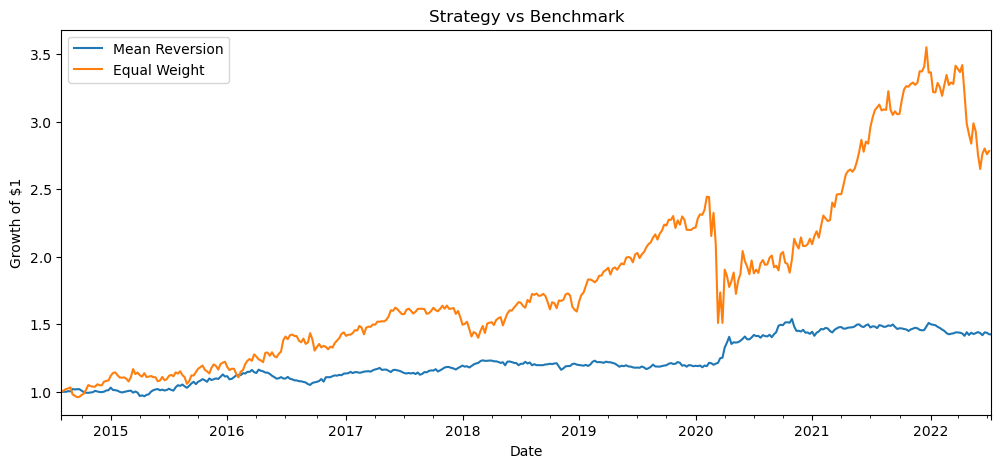

Date
2014-08-01   -0.006820
2014-08-08   -0.000974
2014-08-15   -0.000329
2014-08-22    0.003706
2014-08-29   -0.002392
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: 5.72%
Sharpe ratio: 0.12
Max drawdown: -13.15%
--- Benchmark ---
Total return: 178.29%
Sharpe ratio: 0.67
Max drawdown: -38.24%


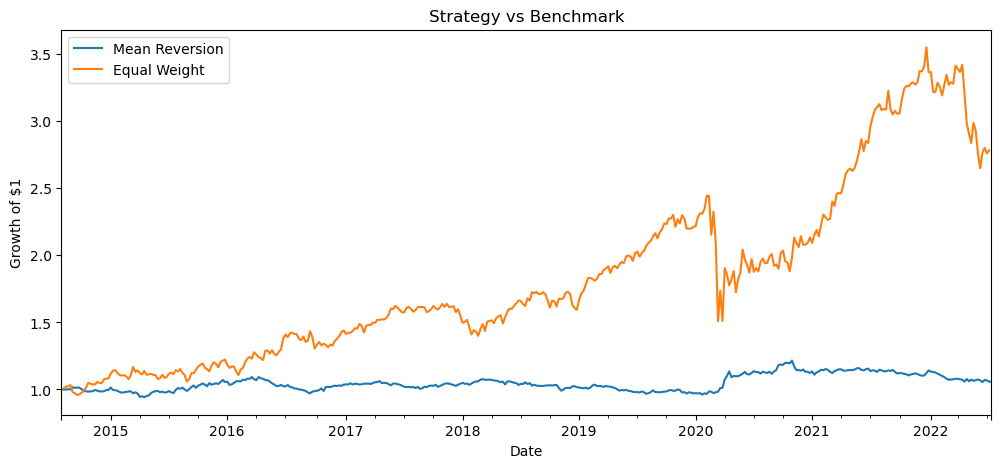

Date
2014-08-01   -0.006820
2014-08-08   -0.002216
2014-08-15   -0.001784
2014-08-22    0.002160
2014-08-29   -0.004197
Freq: W-FRI, dtype: float64
--- Strategy ---
Total return: -41.85%
Sharpe ratio: -0.91
Max drawdown: -42.38%
--- Benchmark ---
Total return: 178.29%
Sharpe ratio: 0.67
Max drawdown: -38.24%


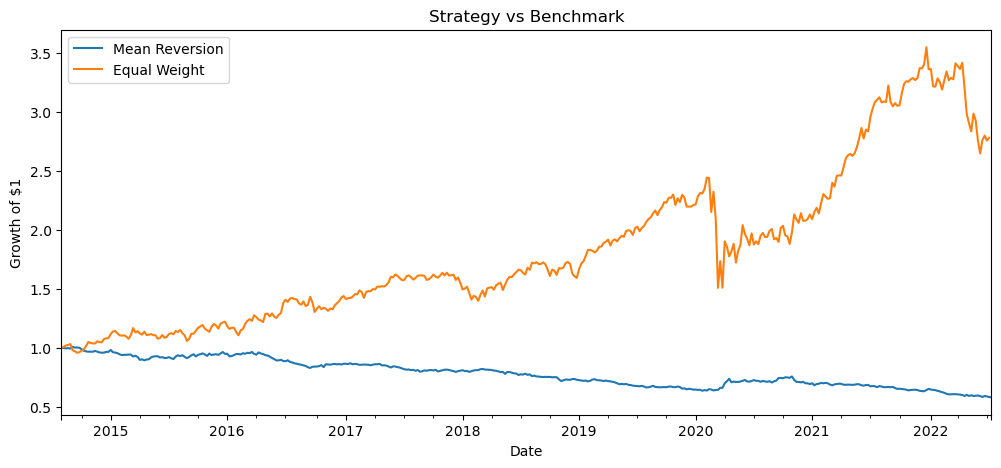

In [6]:
end = df.index.max() - pd.DateOffset(years=4)
start = end - pd.DateOffset(years=12)

cost = [5, 10, 20]

for c in cost:
    strategy = run_backtest(df, start_date=start, end_date=end, cost_bps=c)
    benchmark = run_benchmark(df, start_date=start, end_date=end)

    print("--- Strategy ---")
    print_stats(strategy["stats"])

    print("--- Benchmark ---")
    print_stats(benchmark["stats"])


    equity = strategy["equity"]
    cluster_equity = benchmark["equity"]

    plt.figure(figsize=(12, 5))
    (equity / equity.iloc[0]).plot(label="Mean Reversion")
    (cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
    plt.legend()
    plt.ylabel("Growth of $1")
    plt.title("Strategy vs Benchmark")
    plt.show()

#### Conclusion
When the transaction cost was 5bps, the algorithm performed slightly worse but still tolerable. However, at 10 and 20 bps it was significantly underperforming the very basic equal weight buy and hold strategy. This is expected, as the current strategy as it is rebalances every single week, so the transaction costs add up. This provides a good motivation for meta-labelling, as we will train a machine learning model to selectively pick out which trades to take, which should not only boost the strategy's effectiviness, but also its cost tolerance.

### 3.5 Selecting Tau

For this experiment, I will fix the transaction cost at 10bps for simplicity, as it is very roughly the average commision rate I will experience from different brokers.

In [ ]:
bps = 10

tau_candidates = [
    0.000,   # no threshold
    0.005,   # 0.5%
    0.010,   # 1.0%
    0.015,   # 1.5%
]

